# Cartas de discusion — Dynamic Augmented Pooled Testing

Cada carta es un ejemplo chico con su figura y un par de preguntas abiertas,
pensado para discutir y abrir direcciones. Poco texto: la figura manda.


In [1]:
%matplotlib inline
import os, sys
_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isfile(os.path.join(_d, "augmented", "__init__.py")):
    _d = os.path.dirname(_d)
if not os.path.isfile(os.path.join(_d, "augmented", "__init__.py")):
    _fb = "/Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic"
    if os.path.isfile(os.path.join(_fb, "augmented", "__init__.py")):
        _d = _fb
if _d not in sys.path:
    sys.path.insert(0, _d)
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(0); np.random.seed(0)


## Carta: Donde el arbol del greedy se separa del optimo augmented

Instancia n=4, B=2, G=3 con p=[0.552, 0.122, 0.474, 0.269] y u=[2.735, 2.817, 2.332, 0.82]. El greedy miope abre con un pool singleton (mascara 0b10) y obtiene U_greedy=3.700; el optimo augmented abre con un pool de dos individuos (mascara 0b110), ramifica sobre el conteo exacto de infectados y llega a U_opt=4.187, un gap de 11.6%.

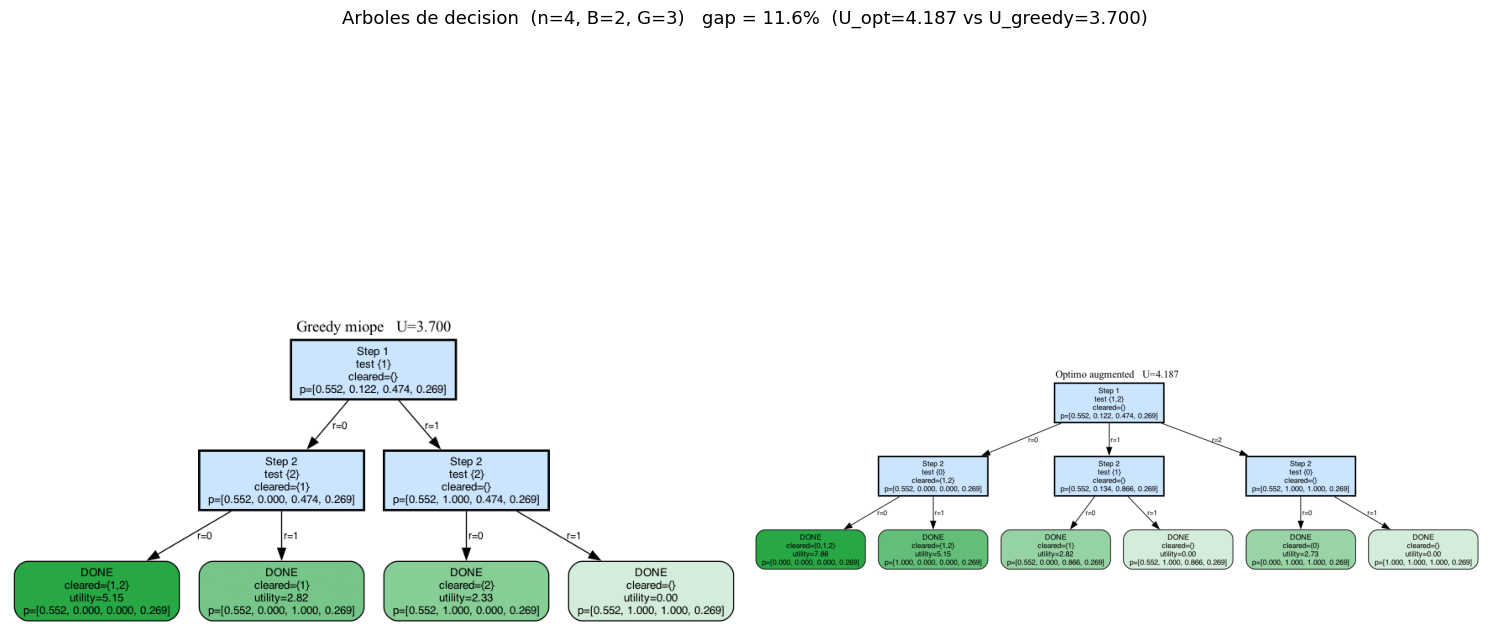

U_opt=4.1870  U_greedy=3.7000  gap=11.63%
primer pool greedy = 0b10, primer pool optimo = 0b110


In [2]:
import io
from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_counting_expected_utility, _myopic_best_pool
from augmented.bayesian import bayesian_update_single_test
from augmented.tree_extractor import extract_tree
from augmented.tree_visualizer import render_tree

# Instancia n=4, B=2, G=3 donde el greedy miope queda por debajo del optimo augmented.
n, B, G = 4, 2, 3
p = [0.552, 0.122, 0.474, 0.269]
u = [2.735, 2.817, 2.332, 0.82]

# Optimo augmented: DP exacta que ramifica sobre el conteo de infectados.
U_opt, pol = solve_optimal_dapts(p, u, B, G)
t_opt = extract_tree(pol, p, u, n)

# El greedy no tiene policy: lo envolvemos con la misma firma choose(k, history).
# Re-jugamos la historia para recuperar cleared_mask y el posterior secuencial,
# y devolvemos el pool miope (el mismo _myopic_best_pool que usa el repo).
class GreedyPolicy:
    def __init__(self, p, u, G, n, B):
        self.p, self.u, self.G, self.n, self.B = p, u, G, n, B
    def choose(self, k, history):
        cur, cleared = list(self.p), 0
        for pool, r in history:
            if pool == 0:
                continue
            if r == 0:
                cleared |= pool
            cur = bayesian_update_single_test(cur, pool, r, self.n)
        return _myopic_best_pool(cur, self.u, self.G, self.n, cleared)

t_gre = extract_tree(GreedyPolicy(p, u, G, n, B), p, u, n)
U_gre = greedy_myopic_counting_expected_utility(p, u, B, G)
gap = (U_opt - U_gre) / U_opt

# render_side_by_side devuelve HTML con SVGs; para una sola figura PNG inline
# rendereamos cada arbol con render_tree y los componemos en un matplotlib figure.
dot_gre = render_tree(t_gre, n, title=f"Greedy miope   U={U_gre:.3f}")
dot_opt = render_tree(t_opt, n, title=f"Optimo augmented   U={U_opt:.3f}")
img_gre = plt.imread(io.BytesIO(dot_gre.pipe(format="png")), format="png")
img_opt = plt.imread(io.BytesIO(dot_opt.pipe(format="png")), format="png")

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for ax, img in zip(axes, (img_gre, img_opt)):
    ax.imshow(img); ax.axis("off")
fig.suptitle(f"Arboles de decision  (n=4, B=2, G=3)   gap = {gap*100:.1f}%  "
             f"(U_opt={U_opt:.3f} vs U_greedy={U_gre:.3f})", fontsize=13, y=0.99)
fig.tight_layout()
plt.show()

print(f"U_opt={U_opt:.4f}  U_greedy={U_gre:.4f}  gap={gap*100:.2f}%")
print(f"primer pool greedy = {bin(GreedyPolicy(p,u,G,n,B).choose(1,()))}, "
      f"primer pool optimo = {bin(pol.choose(1,()))}")

Cross-information: secuencial vs conjunto en el Ejemplo 1

## Carta: Cross-information en el Ejemplo 1 (sec 3.1)

Dos tests augmented que se solapan en el individuo 1 (t1={0,1} con conteo r=1, t2={1,2} con conteo r=0). Comparo el posterior de infeccion calculado test por test (secuencial/local) contra el calculo conjunto exacto sobre todos los mundos consistentes. El conjunto deduce que el individuo 0 esta infectado con probabilidad 1.0; el secuencial lo deja en su prior 0.3. Esa brecha 0.3 -> 1.0 es la informacion cruzada que el update local no captura, y es la misma falla del heuristico producto de marginales P(pool limpio)=prod(1-p) de la sec 4, que se equivoca cuando un subconjunto ya dio positivo.

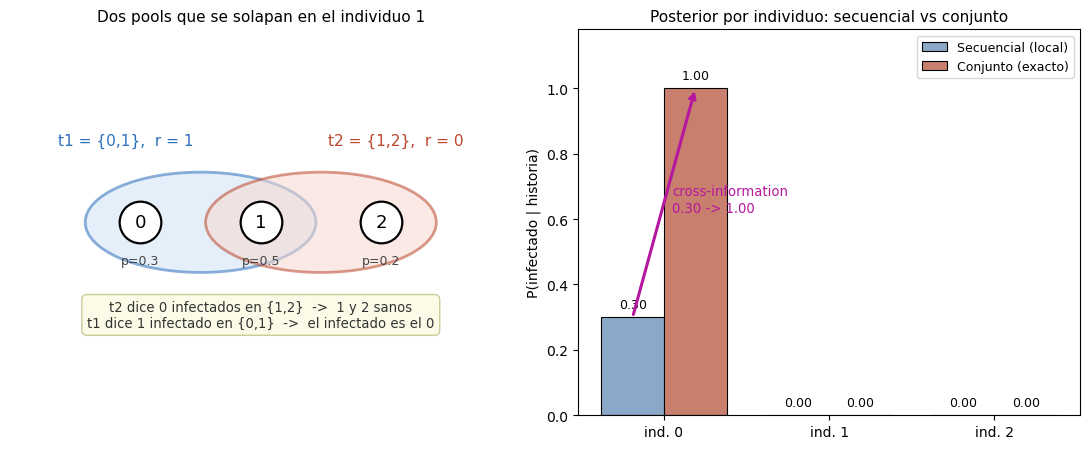

seq  = [0.3, 0.0, 0.0]
joint= [1.0, 0.0, 0.0]


In [3]:
from matplotlib.patches import Ellipse
from augmented.bayesian import bayesian_update, bayesian_update_by_counting

# Ejemplo 1 (sec 3.1): n=3, dos tests con conteo exacto
n = 3
p = [0.3, 0.5, 0.2]
t1 = (1 << 0) | (1 << 1)   # pool {0,1}
t2 = (1 << 1) | (1 << 2)   # pool {1,2}
history = ((t1, 1), (t2, 0))

seq = bayesian_update(p, history, n)                # (a) secuencial / local
joint = bayesian_update_by_counting(p, history, n)  # (b) conjunto exacto

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# Panel izquierdo: los dos pools como elipses que se solapan en el individuo 1
axL.set_xlim(0, 10); axL.set_ylim(0, 10); axL.axis("off")
axL.set_title("Dos pools que se solapan en el individuo 1", fontsize=11)
pos = {0: (2.6, 5.0), 1: (5.0, 5.0), 2: (7.4, 5.0)}
axL.add_patch(Ellipse((3.8, 5.0), 4.6, 2.6, facecolor="#cfe3f7",
                      edgecolor="#2c6fbb", lw=2, alpha=0.55, zorder=1))
axL.add_patch(Ellipse((6.2, 5.0), 4.6, 2.6, facecolor="#f7d8cf",
                      edgecolor="#bb472c", lw=2, alpha=0.55, zorder=1))
axL.text(2.3, 7.0, "t1 = {0,1},  r = 1", color="#2c6fbb", fontsize=11, ha="center")
axL.text(7.7, 7.0, "t2 = {1,2},  r = 0", color="#bb472c", fontsize=11, ha="center")
for i, (x, y) in pos.items():
    axL.scatter([x], [y], s=900, color="white", edgecolors="black", lw=1.6, zorder=3)
    axL.text(x, y, str(i), ha="center", va="center", fontsize=13, zorder=4)
    axL.text(x, y - 1.0, f"p={p[i]:.1f}", ha="center", va="center", fontsize=9, color="#444")
axL.text(5.0, 2.6,
         "t2 dice 0 infectados en {1,2}  ->  1 y 2 sanos\n"
         "t1 dice 1 infectado en {0,1}  ->  el infectado es el 0",
         ha="center", va="center", fontsize=9.5, color="#333",
         bbox=dict(boxstyle="round,pad=0.4", fc="#fbfbe8", ec="#cccc99"))

# Panel derecho: barras agrupadas del posterior P(infectado)
idx = np.arange(n)
w = 0.38
bars_seq = axR.bar(idx - w/2, seq, w, label="Secuencial (local)",
                   color="#8aa9c9", edgecolor="black", lw=0.8)
bars_joint = axR.bar(idx + w/2, joint, w, label="Conjunto (exacto)",
                     color="#c97f6e", edgecolor="black", lw=0.8)
axR.set_xticks(idx); axR.set_xticklabels([f"ind. {i}" for i in idx])
axR.set_ylabel("P(infectado | historia)")
axR.set_ylim(0, 1.18)
axR.set_title("Posterior por individuo: secuencial vs conjunto", fontsize=11)
axR.legend(loc="upper right", fontsize=9)
for b in list(bars_seq) + list(bars_joint):
    h = b.get_height()
    axR.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.2f}",
             ha="center", va="bottom", fontsize=9)
axR.annotate("", xy=(0 + w/2, joint[0]), xytext=(0 - w/2, seq[0]),
             arrowprops=dict(arrowstyle="->", color="#b5179e", lw=2.2))
axR.text(0.05, 0.66, "cross-information\n0.30 -> 1.00", color="#b5179e",
         fontsize=9.5, ha="left", va="center")

fig.tight_layout()
plt.show()

print("seq  =", [round(x, 4) for x in seq])
print("joint=", [round(x, 4) for x in joint])

## Carta: el super-nodo S que aparece tras testear

Testeamos el pool t3 = {3, 6} y salio el conteo r = 1: eso acopla a 3 y 6 en un solo super-nodo S, cuyo posterior conjunto ya no factoriza como producto de marginales.

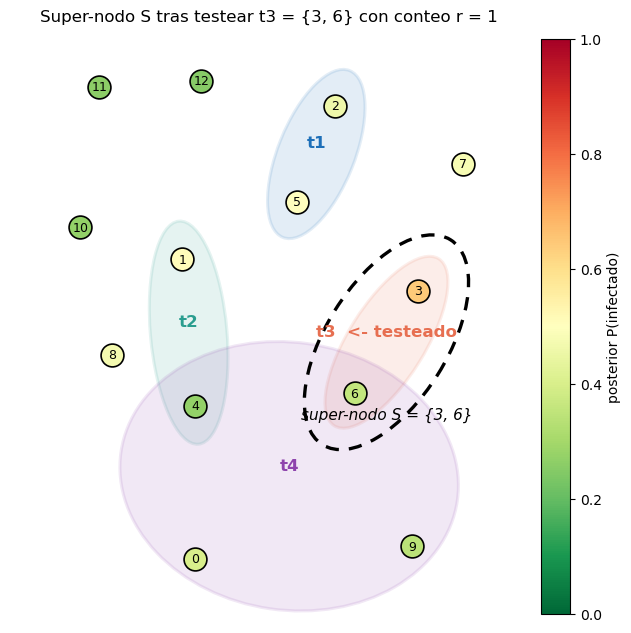

prior p sobre S: {3: 0.24, 6: 0.15}
posterior q sobre S: {3: 0.642, 6: 0.358}
suma de posteriores en S (= r): 1.0


In [4]:
from matplotlib.patches import Ellipse
from augmented.bayesian import bayesian_update_by_counting

# --- Instancia (misma del ejemplo VW) ---
POS = {
    0: (3.2, 1.0), 1: (3.0, 5.7), 2: (5.4, 8.1), 3: (6.7, 5.2), 4: (3.2, 3.4),
    5: (4.8, 6.6), 6: (5.7, 3.6), 7: (7.4, 7.2), 8: (1.9, 4.2),
    9: (6.6, 1.2), 10: (1.4, 6.2), 11: (1.7, 8.4), 12: (3.3, 8.5),
}
POOLS = {"t1": [2, 5], "t2": [1, 4], "t3": [3, 6], "t4": [0, 4, 6, 9]}
N = len(POS)
POOL_COLORS = {"t1": "#1d6fb8", "t2": "#2a9d8f", "t3": "#e76f51", "t4": "#8e44ad"}

rng = np.random.default_rng(7)
p = {i: round(float(rng.uniform(0.15, 0.55)), 2) for i in POS}   # prior P(infectado)
u = {i: int(rng.integers(1, 4)) for i in POS}                    # utilidad


def mask(ids):
    m = 0
    for i in ids:
        m |= (1 << i)
    return m


def ellipse_params(ids, pad=1.2):
    pts = np.array([POS[i] for i in ids], float)
    c = pts.mean(0)
    if len(pts) == 1:
        return c, 1.0, 1.0, 0.0
    d = pts - c
    vals, vecs = np.linalg.eigh(np.cov(d.T) + 1e-6 * np.eye(2))
    proj = d @ vecs
    h = 2 * np.abs(proj[:, 0]).max() + pad
    w = 2 * np.abs(proj[:, 1]).max() + pad
    ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    return c, w, h, ang


def draw_pool(ax, ids, color, lw=2.2, alpha=0.12):
    c, w, h, ang = ellipse_params(ids)
    ax.add_patch(Ellipse(c, w, h, angle=ang, facecolor=color, alpha=alpha,
                         edgecolor=color, lw=lw, zorder=1))
    return c


def draw_supernode(ax, ids):
    c, w, h, ang = ellipse_params(ids, pad=1.9)
    ax.add_patch(Ellipse(c, w, h, angle=ang, facecolor="none",
                         edgecolor="k", lw=2.4, ls=(0, (4, 3)), zorder=2))
    ax.text(c[0], c[1] - h / 2 - 0.25, "super-nodo S = {3, 6}", ha="center",
            fontsize=11, fontstyle="italic", zorder=5)


def draw_agents(ax, post):
    for i, (x, y) in POS.items():
        col = plt.cm.RdYlGn_r(post[i])
        ax.scatter([x], [y], s=270, c=[col], edgecolors="k", linewidths=1.2, zorder=3)
        ax.text(x, y, str(i), ha="center", va="center", fontsize=9, zorder=4)


# --- Posterior tras la historia ((mask{3,6}, 1),) ---
S = [3, 6]
history = ((mask(S), 1),)
q_vec = bayesian_update_by_counting([p[i] for i in range(N)], history, N)
q = {i: q_vec[i] for i in range(N)}

fig, ax = plt.subplots(figsize=(8, 6.5))
for name, ids in POOLS.items():
    c = draw_pool(ax, ids, POOL_COLORS[name])
    lbl = name + "  <- testeado" if name == "t3" else name
    ax.text(c[0], c[1] + 0.1, lbl, color=POOL_COLORS[name],
            fontsize=12, fontweight="bold", ha="center", zorder=5)
draw_supernode(ax, S)
draw_agents(ax, q)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, label="posterior P(infectado)")
ax.set_title("Super-nodo S tras testear t3 = {3, 6} con conteo r = 1")
ax.set_xlim(0.3, 8.4); ax.set_ylim(0, 9.3); ax.set_aspect("equal"); ax.axis("off")
fig.tight_layout()
plt.show()

print("prior p sobre S:", {i: p[i] for i in S})
print("posterior q sobre S:", {i: round(q[i], 3) for i in S})
print("suma de posteriores en S (= r):", round(q[3] + q[6], 3))

Mapa de tratabilidad de la inferencia exacta (Prop. 3)

## Carta: Cuando la posterior exacta es #P-hard y cuando no

La Proposition 3 (sec 6) dice que calcular el marginal posterior exacto P(X_i=0 | Ax=r) bajo tests augmented es #P-hard en general, por reduccion de #Exact Cover: la constante de normalizacion Z es un weighted model count. Pero la sec 6.3 identifica estructuras de pools que si admiten inferencia exacta eficiente. Esta carta dibuja un mapa: arriba el caso general con pools muy solapados (rojo, #P-hard), abajo tres estructuras tratables (verde). Cada caso se muestra como factor graph bipartito: circulos = individuos X_i, cuadrados = tests t_j, arista si el individuo entra en el test.

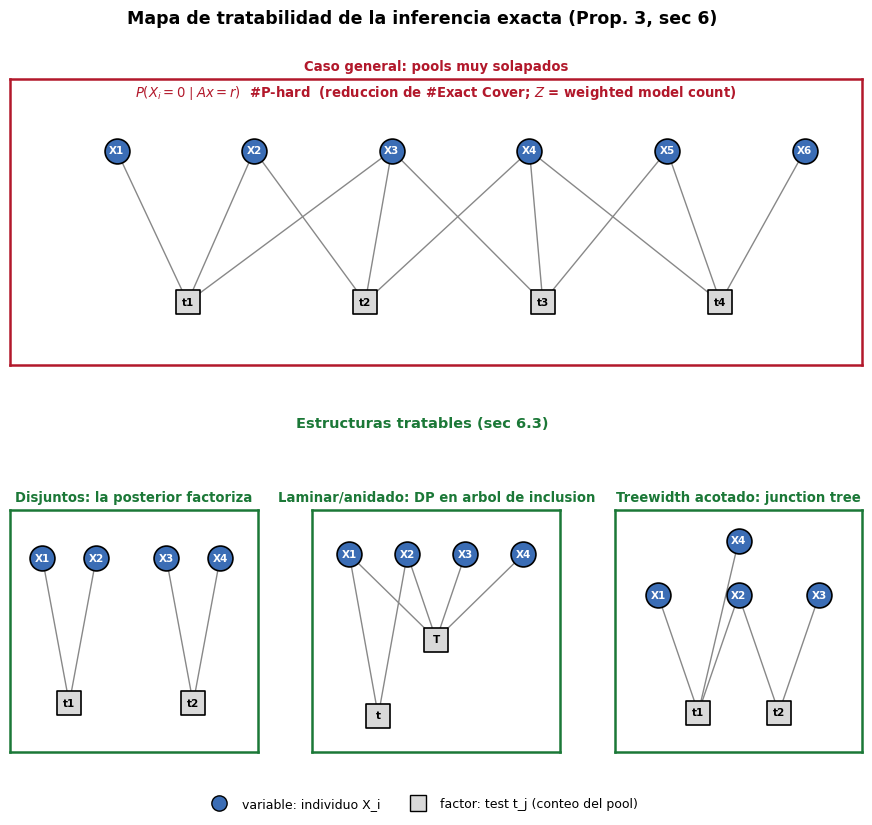

In [5]:
import networkx as nx
from matplotlib.lines import Line2D

GREEN = "#1b7837"; RED = "#b2182b"; VAR_C = "#3b6db5"; FAC_C = "#d9d9d9"

def draw_factor_graph(ax, var_pos, fac_pos, edges, title, color, var_labels=None, fac_labels=None):
    """Factor graph bipartito: variables (circulos) y factores (cuadrados)."""
    for v, f in edges:
        x0, y0 = var_pos[v]; x1, y1 = fac_pos[f]
        ax.plot([x0, x1], [y0, y1], color="#888888", lw=1.0, zorder=1)
    for v, (x, y) in var_pos.items():
        ax.scatter([x], [y], s=320, facecolor=VAR_C, edgecolor="black",
                   linewidth=1.2, zorder=3, marker="o")
        ax.text(x, y, (var_labels[v] if var_labels else v), ha="center", va="center",
                color="white", fontsize=7.5, fontweight="bold", zorder=4)
    for f, (x, y) in fac_pos.items():
        ax.scatter([x], [y], s=300, facecolor=FAC_C, edgecolor="black",
                   linewidth=1.2, zorder=3, marker="s")
        ax.text(x, y, (fac_labels[f] if fac_labels else f), ha="center", va="center",
                color="black", fontsize=7.5, fontweight="bold", zorder=4)
    ax.set_title(title, fontsize=9.5, color=color, fontweight="bold", pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(color); s.set_linewidth(1.8)

fig = plt.figure(figsize=(11, 8.2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.18, 1.0], hspace=0.55, wspace=0.22,
                      top=0.90, bottom=0.08)

# ARRIBA: caso general (#P-hard), pools muy solapados (ni disjuntos ni anidados)
ax_top = fig.add_subplot(gs[0, :])
var_pos = {f"x{i}": (1.2 + 1.55 * i, 2.4) for i in range(6)}
var_labels = {f"x{i}": f"X{i+1}" for i in range(6)}
fac_pos = {"t0": (2.0, 0.7), "t1": (4.0, 0.7), "t2": (6.0, 0.7), "t3": (8.0, 0.7)}
fac_labels = {"t0": "t1", "t1": "t2", "t2": "t3", "t3": "t4"}
edges_top = [("x0","t0"),("x1","t0"),("x2","t0"),
             ("x1","t1"),("x2","t1"),("x3","t1"),
             ("x2","t2"),("x3","t2"),("x4","t2"),
             ("x3","t3"),("x4","t3"),("x5","t3")]
draw_factor_graph(ax_top, var_pos, fac_pos, edges_top,
                  "Caso general: pools muy solapados", RED, var_labels, fac_labels)
ax_top.set_xlim(0, 9.6); ax_top.set_ylim(0.0, 3.2)
ax_top.text(4.8, 3.05,
            r"$P(X_i=0 \mid Ax=r)$  #P-hard  (reduccion de #Exact Cover; $Z$ = weighted model count)",
            ha="center", va="center", fontsize=9.5, color=RED, fontweight="bold")

# ABAJO IZQ: disjuntos -> la posterior factoriza
ax1 = fig.add_subplot(gs[1, 0])
vp = {"x0": (0.6, 2.2), "x1": (1.6, 2.2), "x2": (2.9, 2.2), "x3": (3.9, 2.2)}
vl = {"x0": "X1", "x1": "X2", "x2": "X3", "x3": "X4"}
fp = {"t0": (1.1, 0.7), "t1": (3.4, 0.7)}; fl = {"t0": "t1", "t1": "t2"}
draw_factor_graph(ax1, vp, fp, [("x0","t0"),("x1","t0"),("x2","t1"),("x3","t1")],
                  "Disjuntos: la posterior factoriza", GREEN, vl, fl)
ax1.set_xlim(0, 4.6); ax1.set_ylim(0.2, 2.7)

# ABAJO CENTRO: laminar/anidado -> DP en arbol de inclusion
ax2 = fig.add_subplot(gs[1, 1])
vp = {"x0": (0.7, 2.2), "x1": (1.8, 2.2), "x2": (2.9, 2.2), "x3": (4.0, 2.2)}
vl = {"x0": "X1", "x1": "X2", "x2": "X3", "x3": "X4"}
fp = {"big": (2.35, 1.25), "small": (1.25, 0.4)}; fl = {"big": "T", "small": "t"}
draw_factor_graph(ax2, vp, fp,
                  [("x0","big"),("x1","big"),("x2","big"),("x3","big"),("x0","small"),("x1","small")],
                  "Laminar/anidado: DP en arbol de inclusion", GREEN, vl, fl)
ax2.set_xlim(0, 4.7); ax2.set_ylim(0.0, 2.7)

# ABAJO DER: treewidth acotado -> junction tree
ax3 = fig.add_subplot(gs[1, 2])
vp = {"x0": (0.7, 2.2), "x1": (2.0, 2.2), "x2": (3.3, 2.2), "x3": (2.0, 2.9)}
vl = {"x0": "X1", "x1": "X2", "x2": "X3", "x3": "X4"}
fp = {"t0": (1.35, 0.7), "t1": (2.65, 0.7)}; fl = {"t0": "t1", "t1": "t2"}
draw_factor_graph(ax3, vp, fp,
                  [("x0","t0"),("x1","t0"),("x3","t0"),("x1","t1"),("x2","t1")],
                  "Treewidth acotado: junction tree", GREEN, vl, fl)
ax3.set_xlim(0, 4.0); ax3.set_ylim(0.2, 3.3)

handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=VAR_C,
                  markeredgecolor="black", markersize=11, label="variable: individuo X_i"),
           Line2D([0],[0], marker="s", color="w", markerfacecolor=FAC_C,
                  markeredgecolor="black", markersize=11, label="factor: test t_j (conteo del pool)")]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, -0.005))
fig.suptitle("Mapa de tratabilidad de la inferencia exacta (Prop. 3, sec 6)",
             fontsize=12.5, fontweight="bold", y=0.985)
fig.text(0.5, 0.475, "Estructuras tratables (sec 6.3)", ha="center",
         fontsize=10.5, color=GREEN, fontweight="bold")
plt.show()

## Carta: la fibra de perfiles se parte por total de infectados

Dos pools solapados, ({0,1,2},1) y ({2,3,4},1), dejan cinco perfiles de infeccion validos sobre n=5 agentes. El perfil {2} tiene total 1 y los otros cuatro ({0,3},{0,4},{1,3},{1,4}) tienen total 2. Si la unica movida permitida es un swap sana<->infectada (mover una infeccion de un agente a otro), el grafo de perfiles se parte en dos componentes, porque ningun swap cambia el total.

perfiles validos: ['{2}', '{1,4}', '{1,3}', '{0,4}', '{0,3}']
n componentes: 2
  componente: ['{2}'] -> totales [1]
  componente: ['{0,3}', '{0,4}', '{1,3}', '{1,4}'] -> totales [2]


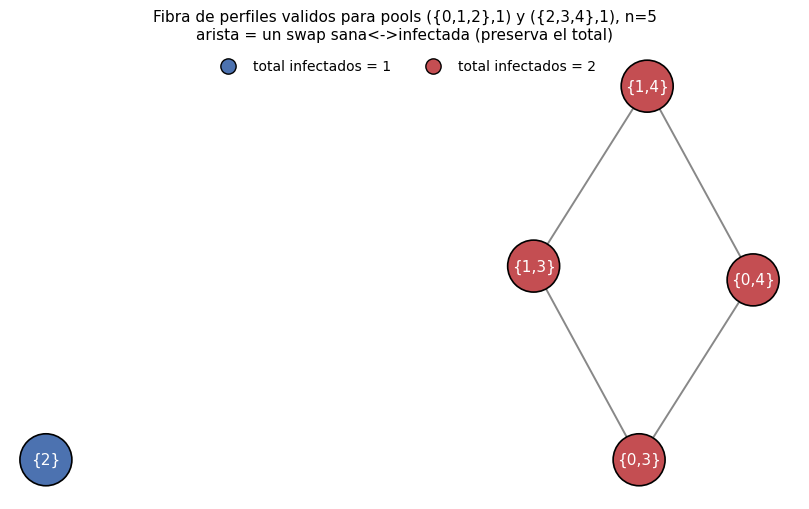

In [6]:
import itertools
import networkx as nx

n = 5
# Historia augmentada: dos pools solapados con conteos exactos.
# Pool A = {0,1,2} con conteo 1 ; Pool B = {2,3,4} con conteo 1.
pools = [(frozenset({0,1,2}), 1), (frozenset({2,3,4}), 1)]

def valid(profile):
    infected = frozenset(i for i in range(n) if profile[i] == 1)
    for pool, cnt in pools:
        if len(infected & pool) != cnt:
            return False
    return True

# Enumeracion por fuerza bruta sobre 2^5, filtrando por los conteos.
profiles = [p for p in itertools.product([0, 1], repeat=n) if valid(p)]

def label(p):
    return "{" + ",".join(str(i) for i in range(n) if p[i] == 1) + "}"

def total(p):
    return sum(p)

# Arista si difieren por UN swap sana<->infectada:
# exactamente un agente pasa 1->0 y otro 0->1 (preserva el total).
def one_swap(a, b):
    diff = [i for i in range(n) if a[i] != b[i]]
    if len(diff) != 2:
        return False
    i, j = diff
    return {a[i], a[j]} == {0, 1} and sum(a) == sum(b)

G = nx.Graph()
for p in profiles:
    G.add_node(p, total=total(p))
for a, b in itertools.combinations(profiles, 2):
    if one_swap(a, b):
        G.add_edge(a, b)

comps = list(nx.connected_components(G))
print("perfiles validos:", [label(p) for p in profiles])
print("n componentes:", nx.number_connected_components(G))
for c in comps:
    tots = sorted(set(total(p) for p in c))
    print("  componente:", sorted(label(p) for p in c), "-> totales", tots)

# --- Figura ---
totals = sorted(set(total(p) for p in profiles))
cmap = {1: "#4C72B0", 2: "#C44E52"}
node_colors = [cmap[total(p)] for p in G.nodes()]

# layout: separa las dos componentes en el eje x
pos = {}
comps_sorted = sorted(comps, key=lambda c: min(total(p) for p in c))
xbase = [0.0, 1.0]
for ci, c in enumerate(comps_sorted):
    nodes = sorted(c, key=lambda p: label(p))
    sub = G.subgraph(c)
    spos = nx.spring_layout(sub, seed=3, k=1.5)
    xs = np.array([spos[nd][0] for nd in nodes])
    ys = np.array([spos[nd][1] for nd in nodes])
    if np.ptp(xs) > 0: xs = (xs - xs.min())/np.ptp(xs)
    if np.ptp(ys) > 0: ys = (ys - ys.min())/np.ptp(ys)
    for k, nd in enumerate(nodes):
        pos[nd] = (xbase[ci] + 0.45*xs[k], ys[k])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888888", width=1.4)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=1400, edgecolors="black", linewidths=1.2)
nx.draw_networkx_labels(G, pos, labels={p: label(p) for p in G.nodes()},
                        ax=ax, font_size=11, font_color="white")

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', linestyle='', markersize=11,
                  markerfacecolor=cmap[t], markeredgecolor='black',
                  label=f"total infectados = {t}") for t in totals]
ax.legend(handles=handles, loc="upper center", frameon=False, ncol=2, fontsize=10)

ax.set_title("Fibra de perfiles validos para pools ({0,1,2},1) y ({2,3,4},1), n=5\n"
             "arista = un swap sana<->infectada (preserva el total)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()